# 04 — Feature Selection (v2)
**Changes from v1:**
- LASSO C grid raised to 0.1–100 (was 0.0001–10)
- Hard minimum of 5 features retained after LASSO
- RFE stops only if removing a feature drops AUC by more than 0.005 (was any drop)
- RFE hard floor at max(4, n_features // 3)
- Works with the expanded ~30-feature pool from notebook 03

Reads from `data/features/` — writes to `data/selected/`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','xgboost','-q'], capture_output=True)

from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import xgboost as xgb
from scipy import stats

with open('/content/drive/MyDrive/CapstoneDA/config.json') as f:
    CFG = json.load(f)

FEATURES = CFG['PATHS']['features']
SELECTED = CFG['PATHS']['selected']
PLOTS    = CFG['PATHS']['plots']
SEED     = CFG['SEED']
ALPHA    = CFG['ALPHA']
JACCARD_THRESHOLD = CFG['JACCARD_THRESHOLD']
np.random.seed(SEED)

sp500 = pd.read_csv(f'{FEATURES}/sp500_features.csv', index_col='Date', parse_dates=['Date'])
nifty = pd.read_csv(f'{FEATURES}/nifty_features.csv', index_col='Date', parse_dates=['Date'])
sp500.index = sp500.index.tz_localize(None)
nifty.index = nifty.index.tz_localize(None)

with open(f'{FEATURES}/feature_registry.json') as f:
    REGISTRY = json.load(f)

SP500_FEATURES    = [f for f in REGISTRY['sp500_all_features'] if f in sp500.columns]
NIFTY_FEATURES    = [f for f in REGISTRY['nifty_all_features'] if f in nifty.columns]
BASELINE_FEATURES = [f for f in REGISTRY['baseline_features']  if f in sp500.columns]
ALT_DATA_FEATURES = [f for f in REGISTRY['alt_data_features']  if f in sp500.columns]
FAMILIES          = REGISTRY['feature_families']
TARGET            = REGISTRY['target_column']

print(f'S&P 500  : {sp500.shape[0]} rows, {len(SP500_FEATURES)} candidate features')
print(f'NIFTY 50 : {nifty.shape[0]} rows, {len(NIFTY_FEATURES)} candidate features')

Mounted at /content/drive
S&P 500  : 2512 rows, 35 candidate features
NIFTY 50 : 2462 rows, 39 candidate features


In [2]:
# Walk-forward window generator
# The key fix here: after loading from CSV, pandas sometimes reads
# dates as strings or keeps timezone. We normalise to tz-naive
# DatetimeIndex before any comparison.

def build_windows(index, train_mo, val_mo, test_mo):
    # Guarantee tz-naive DatetimeIndex
    if hasattr(index, 'tz') and index.tz is not None:
        index = index.tz_localize(None)
    index = pd.DatetimeIndex(index)

    windows   = []
    anchor    = index.min()
    val_start = anchor + pd.DateOffset(months=train_mo)

    while True:
        val_end   = val_start + pd.DateOffset(months=val_mo)
        test_end  = val_end   + pd.DateOffset(months=test_mo)
        if test_end > index.max():
            break
        tr = index[(index >= anchor)    & (index < val_start)]
        va = index[(index >= val_start) & (index < val_end)]
        te = index[(index >= val_end)   & (index < test_end)]
        if len(tr) >= 200 and len(va) >= 20 and len(te) >= 10:
            windows.append((tr, va, te))
        val_start += pd.DateOffset(months=test_mo)

    return windows

# Ensure the dataframe indexes are tz-naive before passing in
sp500.index = pd.DatetimeIndex(sp500.index).tz_localize(None) \
    if sp500.index.tz is None else pd.DatetimeIndex(sp500.index).tz_convert(None)
nifty.index = pd.DatetimeIndex(nifty.index).tz_localize(None) \
    if nifty.index.tz is None else pd.DatetimeIndex(nifty.index).tz_convert(None)

windows_sp500 = build_windows(
    sp500.index, CFG['TRAIN_MONTHS'], CFG['VAL_MONTHS'], CFG['TEST_MONTHS']
)
windows_nifty = build_windows(
    nifty.index, CFG['TRAIN_MONTHS'], CFG['VAL_MONTHS'], CFG['TEST_MONTHS']
)

# Diagnostic — print exactly what the index looks like so errors are obvious
print(f'S&P 500 index: {len(sp500)} rows | dtype={sp500.index.dtype}')
print(f'  range: {sp500.index.min().date()} to {sp500.index.max().date()}')
print(f'NIFTY 50 index: {len(nifty)} rows | dtype={nifty.index.dtype}')
print(f'  range: {nifty.index.min().date()} to {nifty.index.max().date()}')
print()
print(f'Train months: {CFG["TRAIN_MONTHS"]}  Val: {CFG["VAL_MONTHS"]}  Test: {CFG["TEST_MONTHS"]}')
print(f'First val_start would be: '
      f'{(sp500.index.min() + pd.DateOffset(months=CFG["TRAIN_MONTHS"])).date()}')
print()
print(f'Windows generated: S&P 500 = {len(windows_sp500)},  NIFTY 50 = {len(windows_nifty)}')

if len(windows_sp500) == 0:
    print()
    print('ERROR: No windows generated for S&P 500.')
    print('Most likely cause: the feature CSV date range is shorter than TRAIN_MONTHS.')
    print('Check that notebook 03 completed fully and saved the correct date range.')
    raise ValueError('No walk-forward windows generated. See diagnostic above.')

if len(windows_nifty) == 0:
    print()
    print('ERROR: No windows generated for NIFTY 50.')
    raise ValueError('No walk-forward windows generated for NIFTY 50.')

# Print window 1 details for confirmation
tr, va, te = windows_sp500[0]
print(f'Window 1 — train {tr[0].date()} to {tr[-1].date()} ({len(tr)} days)')
print(f'           val   {va[0].date()} to {va[-1].date()} ({len(va)} days)')
print(f'           test  {te[0].date()} to {te[-1].date()} ({len(te)} days)')

S&P 500 index: 2512 rows | dtype=datetime64[ns]
  range: 2016-01-04 to 2025-12-29
NIFTY 50 index: 2462 rows | dtype=datetime64[ns]
  range: 2016-01-04 to 2025-12-29

Train months: 60  Val: 12  Test: 3
First val_start would be: 2021-01-04

Windows generated: S&P 500 = 15,  NIFTY 50 = 15
Window 1 — train 2016-01-04 to 2020-12-31 (1259 days)
           val   2021-01-04 to 2022-01-03 (253 days)
           test  2022-01-04 to 2022-04-01 (62 days)


In [3]:
# -----------------------------------------------------------------------
# Stage 1: LASSO
# Key changes from v1:
#   - C grid now covers 0.1 to 100 (less aggressive regularisation)
#   - Hard floor: if LASSO keeps fewer than 5 features, we relax C
#     progressively until at least 5 survive
# -----------------------------------------------------------------------

MIN_FEATURES_LASSO = 5

def stage1_lasso(X_train, y_train):
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_train)
    tscv   = TimeSeriesSplit(n_splits=5)

    # Wider C grid — less aggressive than before
    C_values = np.logspace(-1, 2, 25)   # 0.1 to 100

    best_C, best_auc = 1.0, 0.0
    for C in C_values:
        lr = LogisticRegression(C=C, penalty='l1', solver='liblinear',
                                max_iter=2000, random_state=SEED)
        fold_aucs = []
        for tr_i, va_i in tscv.split(X_sc):
            lr.fit(X_sc[tr_i], y_train.iloc[tr_i])
            prob = lr.predict_proba(X_sc[va_i])[:,1]
            if len(np.unique(y_train.iloc[va_i])) > 1:
                fold_aucs.append(roc_auc_score(y_train.iloc[va_i], prob))
        if fold_aucs and np.mean(fold_aucs) > best_auc:
            best_auc = np.mean(fold_aucs)
            best_C   = C

    # Fit with best C
    lr_best = LogisticRegression(C=best_C, penalty='l1', solver='liblinear',
                                  max_iter=2000, random_state=SEED)
    lr_best.fit(X_sc, y_train)
    selected = X_train.columns[np.abs(lr_best.coef_[0]) > 1e-6].tolist()

    # Floor: if too few survived, progressively relax until we have enough
    if len(selected) < MIN_FEATURES_LASSO:
        for C_relax in [5.0, 10.0, 50.0, 100.0]:
            lr_r = LogisticRegression(C=C_relax, penalty='l1', solver='liblinear',
                                      max_iter=2000, random_state=SEED)
            lr_r.fit(X_sc, y_train)
            sel_r = X_train.columns[np.abs(lr_r.coef_[0]) > 1e-6].tolist()
            if len(sel_r) >= MIN_FEATURES_LASSO:
                selected = sel_r
                best_C   = C_relax
                break

    # Final fallback: keep all if still below floor
    if len(selected) < MIN_FEATURES_LASSO:
        selected = X_train.columns.tolist()

    return selected, best_C

In [4]:
# -----------------------------------------------------------------------
# Stage 2: XGBoost RFE
# Key changes from v1:
#   - Stops only if removal drops AUC by more than 0.005 (tolerance)
#   - Hard floor: never go below max(4, n_features // 3)
# -----------------------------------------------------------------------

RFE_AUC_TOLERANCE = 0.005   # only remove if it drops AUC less than this

def stage2_rfe(X_train, y_train, X_val, y_val):
    current   = X_train.columns.tolist()
    best_feats = current.copy()
    min_feats  = max(4, len(current) // 3)

    # Get baseline AUC with all features
    model = xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', random_state=SEED, verbosity=0)
    model.fit(X_train[current], y_train)
    if len(np.unique(y_val)) < 2:
        return current
    best_auc = roc_auc_score(y_val, model.predict_proba(X_val[current])[:,1])

    while len(current) > min_feats:
        model = xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1,
                                   subsample=0.8, colsample_bytree=0.8,
                                   eval_metric='logloss', random_state=SEED, verbosity=0)
        model.fit(X_train[current], y_train)

        if len(np.unique(y_val)) < 2:
            break

        auc = roc_auc_score(y_val, model.predict_proba(X_val[current])[:,1])

        # Only update best if meaningful improvement
        if auc > best_auc - RFE_AUC_TOLERANCE:
            if auc > best_auc:
                best_auc   = auc
                best_feats = current.copy()

        # If removing the weakest feature would drop AUC too much, stop
        imp     = pd.Series(model.feature_importances_, index=current)
        weakest = imp.idxmin()
        trial   = [f for f in current if f != weakest]

        # Quick check: what AUC do we get without the weakest feature?
        if len(trial) >= min_feats:
            m_trial = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                                         eval_metric='logloss', random_state=SEED, verbosity=0)
            m_trial.fit(X_train[trial], y_train)
            auc_trial = roc_auc_score(y_val, m_trial.predict_proba(X_val[trial])[:,1])
            if auc_trial < auc - RFE_AUC_TOLERANCE:
                break   # removing this feature hurts too much

        current.remove(weakest)

    return best_feats if best_feats else current

In [5]:
# Pre-flight check — confirm the data is ready before running selection
# This catches the most common causes of IndexError in the next cell.

print('Pre-flight check:')

# 1. Check that SP500_FEATURES exist in the dataframe
missing_sp = [f for f in SP500_FEATURES if f not in sp500.columns]
missing_ni = [f for f in NIFTY_FEATURES if f not in nifty.columns]
if missing_sp:
    print(f'  WARNING: {len(missing_sp)} S&P 500 features missing from dataframe:')
    print(f'    {missing_sp}')
    print('  Likely cause: notebook 03 v2 was not run, or the wrong version was run.')
else:
    print(f'  S&P 500 features OK ({len(SP500_FEATURES)} expected, all present)')

if missing_ni:
    print(f'  WARNING: {len(missing_ni)} NIFTY 50 features missing from dataframe:')
    print(f'    {missing_ni}')
else:
    print(f'  NIFTY 50 features OK ({len(NIFTY_FEATURES)} expected, all present)')

# 2. Check date ranges are long enough for the walk-forward design
min_days_needed = (CFG['TRAIN_MONTHS'] + CFG['VAL_MONTHS'] + CFG['TEST_MONTHS']) * 21
sp_days = len(sp500)
ni_days = len(nifty)
print(f'  S&P 500 rows   : {sp_days} (need > {min_days_needed})')
print(f'  NIFTY 50 rows  : {ni_days} (need > {min_days_needed})')
if sp_days < min_days_needed or ni_days < min_days_needed:
    print('  ERROR: Not enough rows. Re-run notebook 03 v2.')

# 3. Check windows were built
print(f'  Windows built  : SP500={len(windows_sp500)}, NIFTY={len(windows_nifty)}')
if len(windows_sp500) == 0 or len(windows_nifty) == 0:
    print('  ERROR: No windows. Scroll up and re-run the build_windows cell.')
else:
    print('  All checks passed. Proceeding with feature selection.')

Pre-flight check:
  S&P 500 features OK (35 expected, all present)
  NIFTY 50 features OK (39 expected, all present)
  S&P 500 rows   : 2512 (need > 1575)
  NIFTY 50 rows  : 2462 (need > 1575)
  Windows built  : SP500=15, NIFTY=15
  All checks passed. Proceeding with feature selection.


In [6]:
# Two-stage selection on window 1

def run_selection(feat_df, feat_cols, windows, label):
    if len(windows) == 0:
        raise ValueError(f'{label}: no walk-forward windows available. '
                         'Re-run the build_windows cell first.')

    tr_idx, va_idx, _ = windows[0]

    # Keep features that exist in the dataframe and have enough non-null values
    avail = [
        f for f in feat_cols
        if f in feat_df.columns
        and feat_df[f].notna().sum() > 50
    ]

    if not avail:
        raise ValueError(f'{label}: none of the expected feature columns '
                         'were found in the dataframe. Check that notebook 03 v2 '
                         'was run and saved the correct feature names.')

    X_tr = feat_df.loc[tr_idx, avail].fillna(0)
    y_tr = feat_df.loc[tr_idx, TARGET]
    X_va = feat_df.loc[va_idx, avail].fillna(0)
    y_va = feat_df.loc[va_idx, TARGET]

    # Only keep features present in both train and val
    common = [f for f in avail if f in X_va.columns]

    if len(common) < 3:
        raise ValueError(f'{label}: fewer than 3 features available after alignment. '
                         f'Found: {common}')

    print(f'{label} — {len(common)} input features')
    print(f'  Train: {len(X_tr)} rows   Val: {len(X_va)} rows')

    # Check class balance — warn if one class dominates
    up_rate = y_tr.mean()
    if up_rate < 0.3 or up_rate > 0.7:
        print(f'  Warning: class imbalance in training window (up-rate = {up_rate:.1%})')

    s1, C = stage1_lasso(X_tr[common], y_tr)
    s1c   = [f for f in s1 if f in X_va.columns]
    print(f'  LASSO (C={C:.4f}): {len(s1c)} features kept')

    s2 = stage2_rfe(X_tr[s1c], y_tr, X_va[s1c], y_va)
    print(f'  RFE final        : {len(s2)} features')
    print(f'  Selected         : {s2}')
    return s2

print('Running feature selection (takes a few minutes per market)...')
print()
selected_sp500 = run_selection(sp500, SP500_FEATURES, windows_sp500, 'S&P 500')
print()
selected_nifty = run_selection(nifty, NIFTY_FEATURES, windows_nifty, 'NIFTY 50')

Running feature selection (takes a few minutes per market)...

S&P 500 — 35 input features
  Train: 1259 rows   Val: 253 rows
  LASSO (C=0.1000): 18 features kept
  RFE final        : 18 features
  Selected         : ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_2', 'Log_Ret_5', 'Ret_Mean_5', 'RSI_5', 'Above_MA50', 'VIX_Level', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Level', 'FG_Delta', 'FG_Zone', 'FG_MA5', 'SVI_Index', 'FG_x_SVI', 'Vol_Adj_Ret']

NIFTY 50 — 39 input features
  Train: 1229 rows   Val: 248 rows
  LASSO (C=1.7783): 35 features kept
  RFE final        : 34 features
  Selected         : ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_5', 'Ret_Mean_5', 'Ret_Mean_10', 'Ret_Mean_20', 'Ret_Std_5', 'Ret_Std_10', 'RSI_14', 'RSI_5', 'MACD_Signal', 'MACD_Hist', 'ATR_14', 'Above_MA50', 'Price_MA50', 'VIX_Change', 'VIX_Level', 'VIX_Regime', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Delta', 'FG_Zone', 'FG_Extreme', 'SVI_Market', 'SVI_Index', 'SVI_Mom', 'FG_x_SVI', 'Vol_Adj_Ret', 'VIX_x_Spr

In [7]:
# -----------------------------------------------------------------------
# Jaccard Stability Audit
# Same logic as v1, now operates on the richer feature pool.
# -----------------------------------------------------------------------

def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

def run_jaccard_audit(feat_df, feat_cols, windows, families, label, max_win=8):
    n          = min(max_win, len(windows))
    selections = []

    for i, (tr_idx, va_idx, _) in enumerate(windows[:n]):
        avail  = [f for f in feat_cols if f in feat_df.columns
                  and feat_df[f].notna().sum() > 50]
        X_tr   = feat_df.loc[tr_idx, avail].fillna(0)
        y_tr   = feat_df.loc[tr_idx, TARGET]
        X_va   = feat_df.loc[va_idx, avail].fillna(0)
        y_va   = feat_df.loc[va_idx, TARGET]
        common = [f for f in avail if f in X_va.columns]

        print(f'  {label} window {i+1}/{n}...', end=' ', flush=True)
        try:
            s1, _ = stage1_lasso(X_tr[common], y_tr)
            s1c   = [f for f in s1 if f in X_va.columns]
            s2    = stage2_rfe(X_tr[s1c], y_tr, X_va[s1c], y_va)
            selections.append(set(s2))
            print(f'{len(s2)} features')
        except Exception as e:
            selections.append(set())
            print(f'error: {e}')

    records = []
    for i in range(len(selections) - 1):
        si, sj = selections[i], selections[i+1]
        records.append({'Window': f'W{i+1}-W{i+2}', 'Family': 'overall',
                        'Jaccard': jaccard(si, sj)})
        for fam, feats in families.items():
            fi = si & set(feats)
            fj = sj & set(feats)
            records.append({'Window': f'W{i+1}-W{i+2}', 'Family': fam,
                            'Jaccard': jaccard(fi, fj)})
    return pd.DataFrame(records)

print('Jaccard audit (8 windows per market)...')
jac_sp500 = run_jaccard_audit(sp500, SP500_FEATURES, windows_sp500, FAMILIES, 'S&P 500')
print()
jac_nifty = run_jaccard_audit(nifty, NIFTY_FEATURES, windows_nifty, FAMILIES, 'NIFTY 50')

print('\nJaccard means by family:')
for label, df in [('S&P 500', jac_sp500), ('NIFTY 50', jac_nifty)]:
    print(f'  {label}')
    print(df.groupby('Family')['Jaccard'].mean().round(3).to_string())

Jaccard audit (8 windows per market)...
  S&P 500 window 1/8... 18 features
  S&P 500 window 2/8... 19 features
  S&P 500 window 3/8... 15 features
  S&P 500 window 4/8... 16 features
  S&P 500 window 5/8... 18 features
  S&P 500 window 6/8... 19 features
  S&P 500 window 7/8... 21 features
  S&P 500 window 8/8... 18 features

  NIFTY 50 window 1/8... 34 features
  NIFTY 50 window 2/8... 37 features
  NIFTY 50 window 3/8... 26 features
  NIFTY 50 window 4/8... 25 features
  NIFTY 50 window 5/8... 22 features
  NIFTY 50 window 6/8... 27 features
  NIFTY 50 window 7/8... 25 features
  NIFTY 50 window 8/8... 21 features

Jaccard means by family:
  S&P 500
Family
fear_greed     0.893
interaction    0.857
macro          0.871
overall        0.801
svi            0.714
technical      0.747
  NIFTY 50
Family
fear_greed     0.821
interaction    0.952
macro          0.833
overall        0.815
svi            0.857
technical      0.730


In [8]:
# H2 test: paired t-test, alt-data Jaccard < technical Jaccard

def h2_test(jdf, label):
    alt  = jdf[jdf['Family'].isin(['fear_greed','svi'])].groupby('Window')['Jaccard'].mean()
    tech = jdf[jdf['Family'] == 'technical'].groupby('Window')['Jaccard'].mean()
    common = alt.index.intersection(tech.index)
    if len(common) < 3:
        print(f'{label}: not enough windows')
        return None
    diff          = alt.loc[common] - tech.loc[common]
    t, p_two      = stats.ttest_1samp(diff, 0)
    p_one         = p_two / 2 if t < 0 else 1 - p_two / 2
    print(f'{label} — mean J(alt)={alt.mean():.3f}  J(tech)={tech.mean():.3f}  '
          f't={t:.3f}  p={p_one:.4f}  reject={p_one < 0.05}')
    return {'Market': label, 'Mean_J_alt': alt.mean().round(4),
            'Mean_J_tech': tech.mean().round(4), 'diff': diff.mean().round(4),
            't': round(t,3), 'p_one_tail': round(p_one,4), 'Reject_H0': p_one < 0.05}

print('H2 results:')
h2_sp = h2_test(jac_sp500, 'S&P 500')
h2_ni = h2_test(jac_nifty, 'NIFTY 50')
h2_df = pd.DataFrame([r for r in [h2_sp, h2_ni] if r])

H2 results:
S&P 500 — mean J(alt)=0.804  J(tech)=0.747  t=0.684  p=0.7402  reject=False
NIFTY 50 — mean J(alt)=0.839  J(tech)=0.730  t=1.476  p=0.9047  reject=False


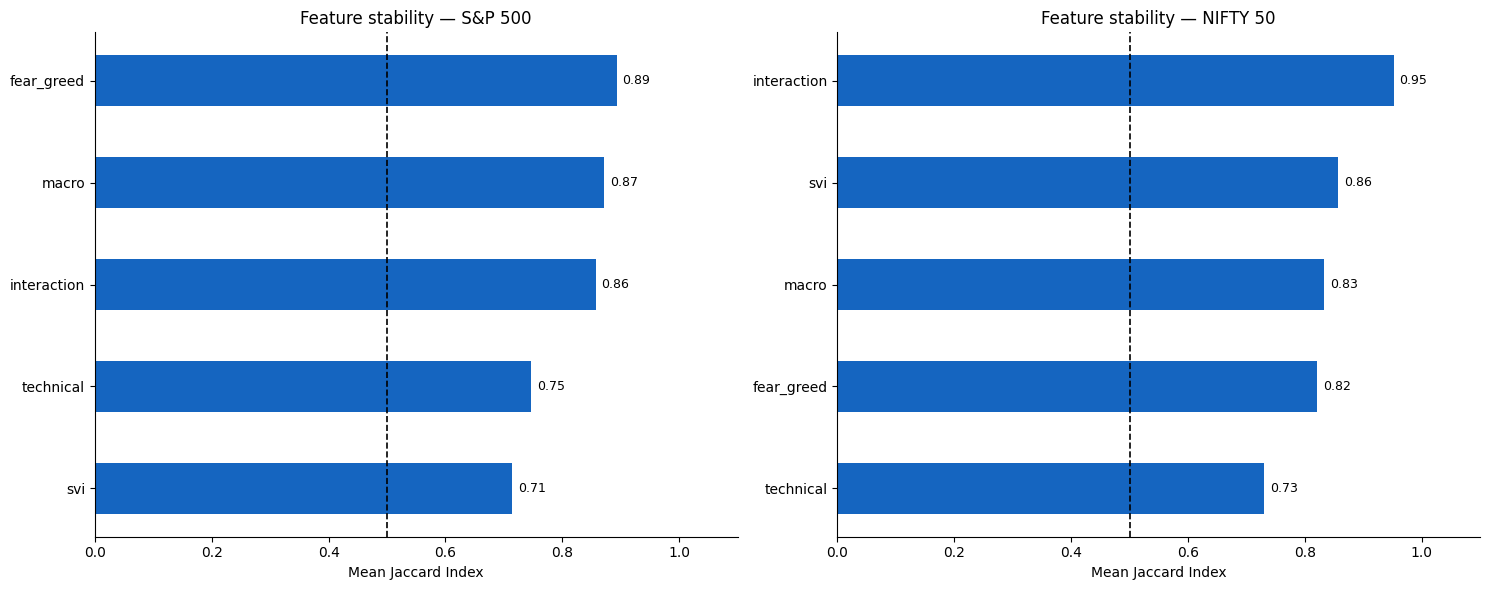

In [9]:
# Jaccard stability chart

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, jdf, label in [(axes[0], jac_sp500, 'S&P 500'), (axes[1], jac_nifty, 'NIFTY 50')]:
    fam_means = (jdf[jdf['Family'] != 'overall']
                 .groupby('Family')['Jaccard'].mean().sort_values())
    colors = ['#c62828' if v < JACCARD_THRESHOLD else '#1565c0' for v in fam_means]
    bars   = ax.barh(fam_means.index, fam_means.values, color=colors, height=0.5)
    ax.axvline(JACCARD_THRESHOLD, color='black', linestyle='--', linewidth=1.2)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('Mean Jaccard Index')
    ax.set_title(f'Feature stability — {label}')
    for bar, val in zip(bars, fam_means.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS}/04_jaccard_stability_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Save all outputs

import os
os.makedirs(SELECTED, exist_ok=True)

def serialize_windows(windows):
    return [{'train_start': str(tr[0].date()), 'train_end': str(tr[-1].date()),
             'val_start':   str(va[0].date()), 'val_end':   str(va[-1].date()),
             'test_start':  str(te[0].date()), 'test_end':  str(te[-1].date()),
             'train_n': len(tr), 'val_n': len(va), 'test_n': len(te)}
            for tr, va, te in windows]

sel_out = {
    'selected_sp500'   : selected_sp500,
    'selected_nifty'   : selected_nifty,
    'baseline_features': BASELINE_FEATURES,
    'alt_data_features': ALT_DATA_FEATURES,
    'feature_families' : FAMILIES,
    'target_column'    : TARGET,
    'n_windows_sp500'  : len(windows_sp500),
    'n_windows_nifty'  : len(windows_nifty),
    'rfe_tolerance'    : RFE_AUC_TOLERANCE,
    'lasso_min_features': MIN_FEATURES_LASSO,
}
with open(f'{SELECTED}/selected_features.json','w') as f:
    json.dump(sel_out, f, indent=2)

with open(f'{SELECTED}/windows_sp500.json','w') as f:
    json.dump(serialize_windows(windows_sp500), f, indent=2)
with open(f'{SELECTED}/windows_nifty.json','w') as f:
    json.dump(serialize_windows(windows_nifty), f, indent=2)

jac_sp500.to_csv(f'{SELECTED}/jaccard_sp500.csv', index=False)
jac_nifty.to_csv(f'{SELECTED}/jaccard_nifty.csv', index=False)
h2_df.to_csv(f'{SELECTED}/h2_test_results.csv', index=False)

print('Saved to data/selected/')
print(f'  S&P 500 selected : {selected_sp500}')
print(f'  NIFTY 50 selected: {selected_nifty}')

Saved to data/selected/
  S&P 500 selected : ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_2', 'Log_Ret_5', 'Ret_Mean_5', 'RSI_5', 'Above_MA50', 'VIX_Level', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Level', 'FG_Delta', 'FG_Zone', 'FG_MA5', 'SVI_Index', 'FG_x_SVI', 'Vol_Adj_Ret']
  NIFTY 50 selected: ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_5', 'Ret_Mean_5', 'Ret_Mean_10', 'Ret_Mean_20', 'Ret_Std_5', 'Ret_Std_10', 'RSI_14', 'RSI_5', 'MACD_Signal', 'MACD_Hist', 'ATR_14', 'Above_MA50', 'Price_MA50', 'VIX_Change', 'VIX_Level', 'VIX_Regime', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Delta', 'FG_Zone', 'FG_Extreme', 'SVI_Market', 'SVI_Index', 'SVI_Mom', 'FG_x_SVI', 'Vol_Adj_Ret', 'VIX_x_Spread', 'USDINR_Ret', 'SP500_t1_Ret', 'FG_t1_Level', 'FG_t1_Delta']
